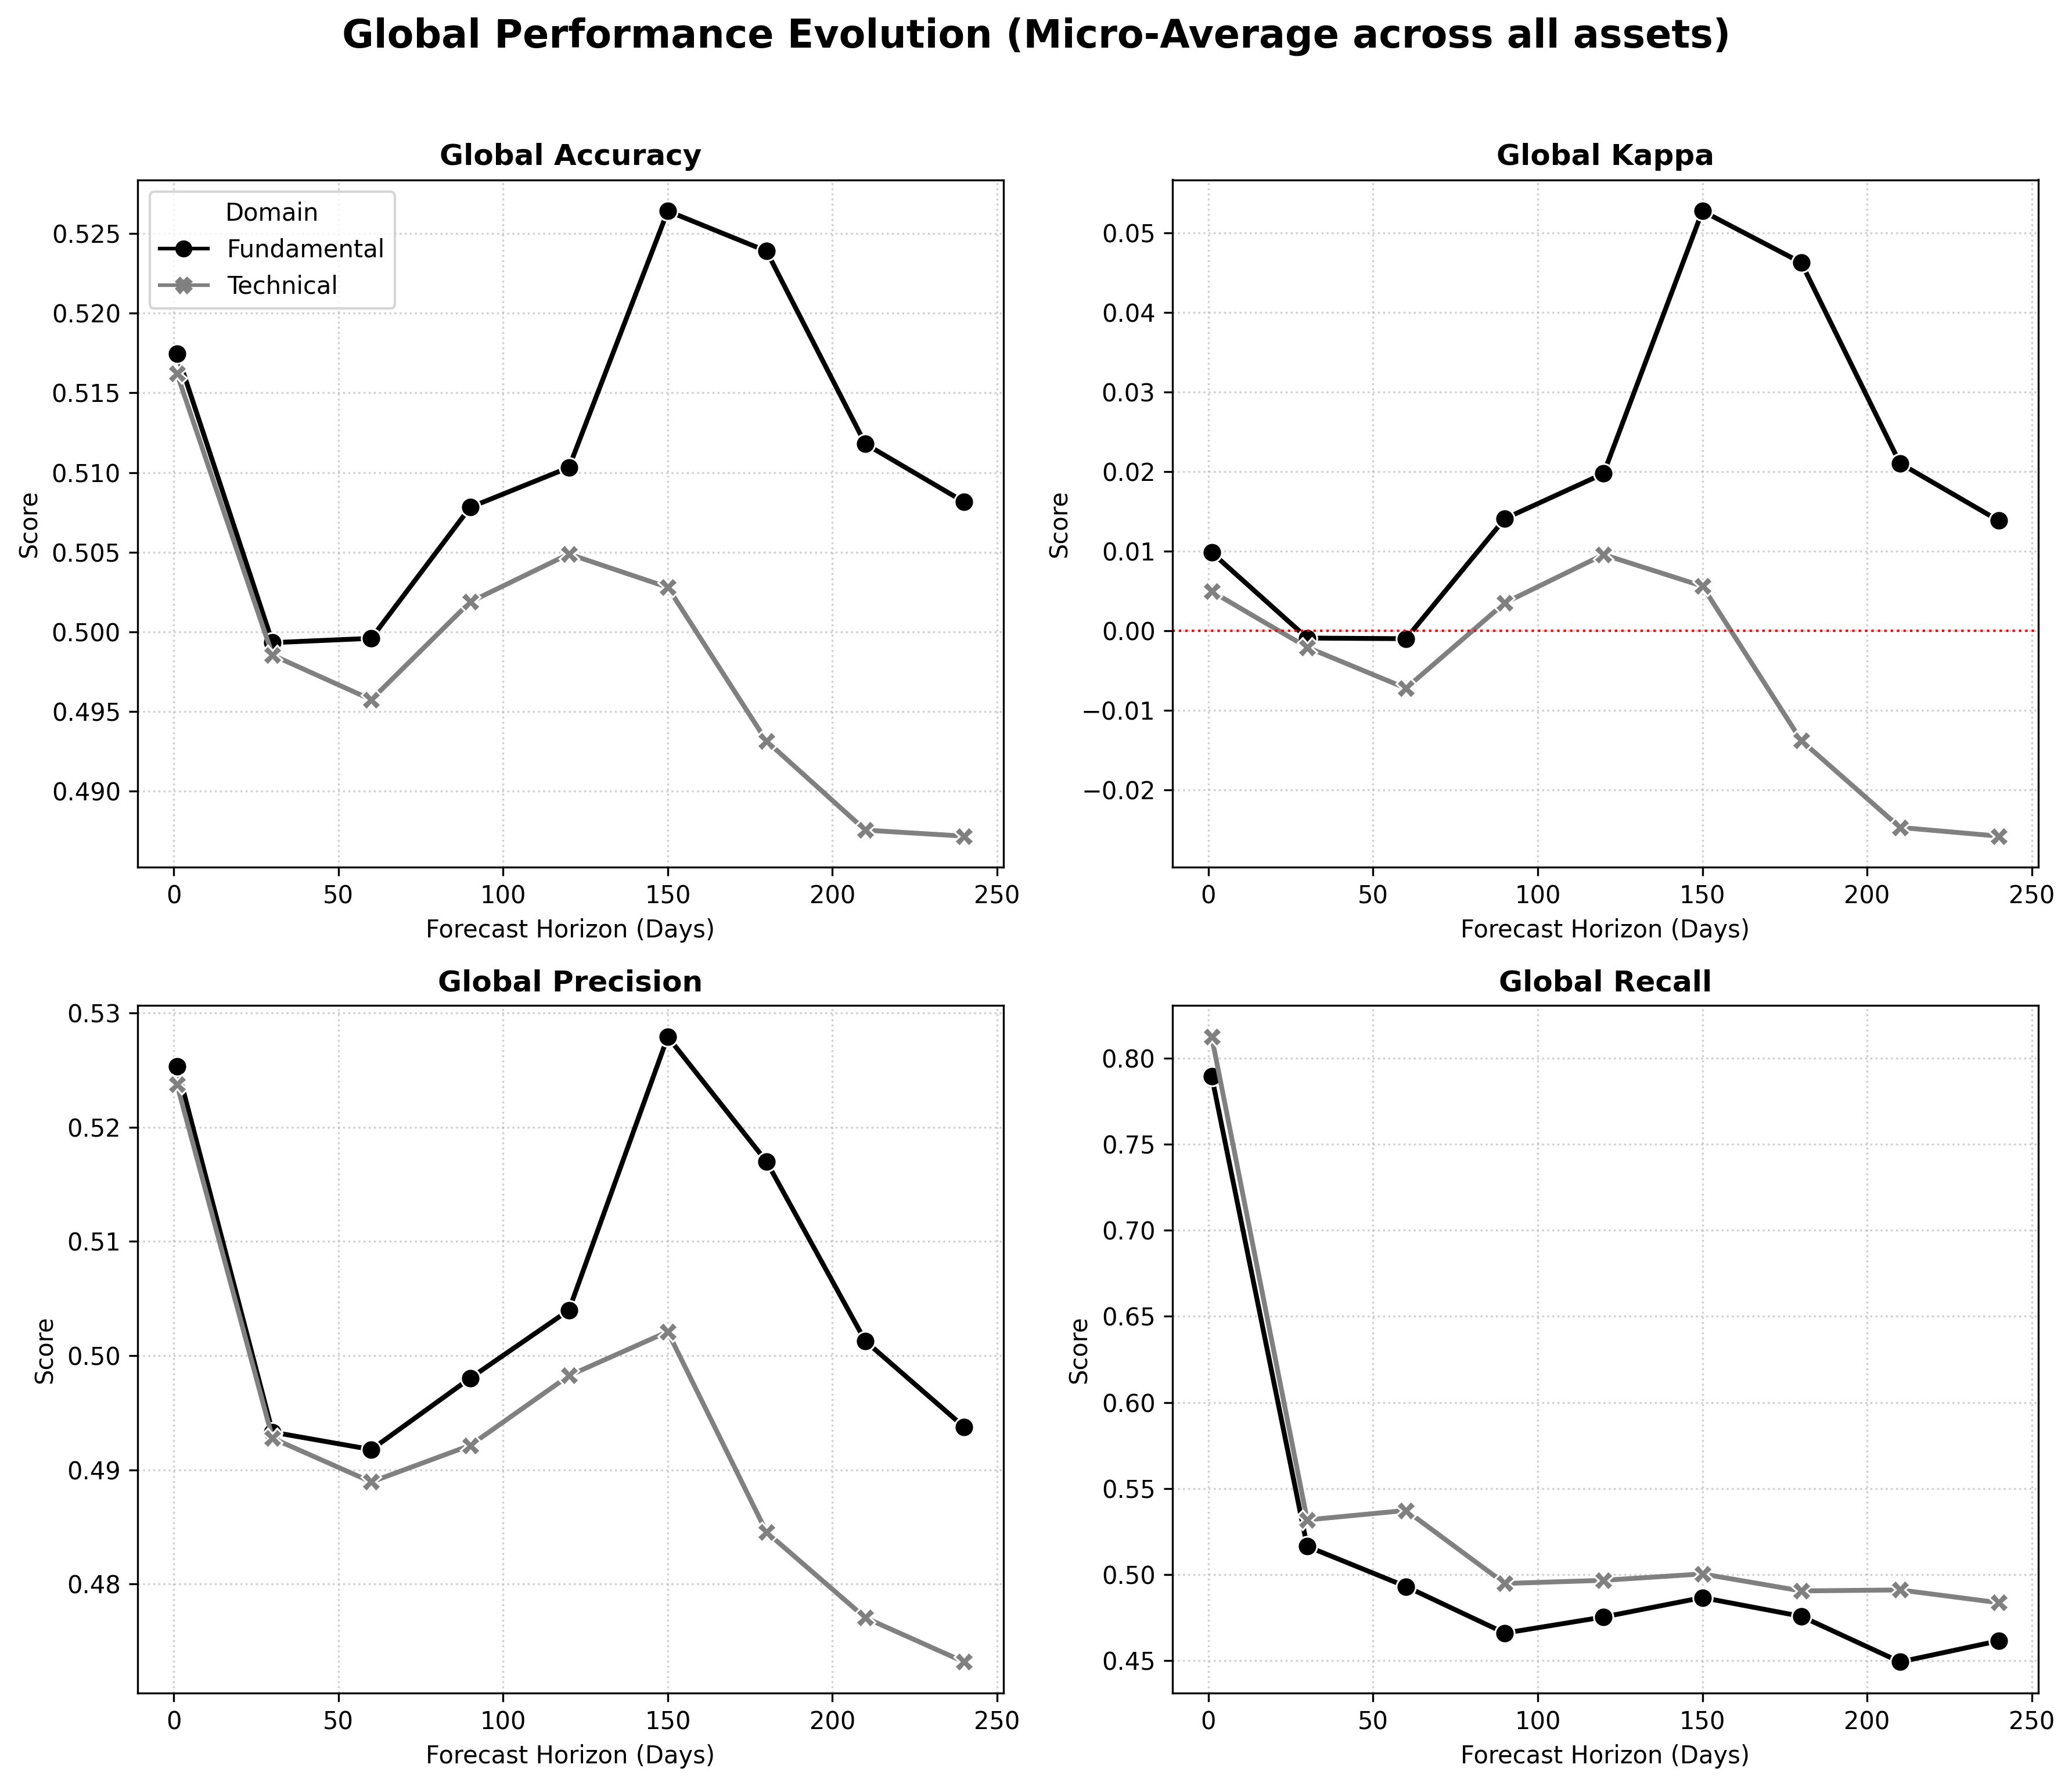

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1
caminho_base = 'resultados'
nome_arquivo_saida = 'global_metrics_by_horizon.pdf'

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
cores = {'Fundamental': 'black', 'Technical': 'gray'}

# --- CORREÇÃO AQUI ---
# Definimos explicitamente quais símbolos usar. 
# 'o' = bolinha, 'X' = xis (X maiúsculo fica mais visível que x minúsculo)
marcadores = {'Fundamental': 'o', 'Technical': 'X'} 
# ---------------------

# ==============================================================================
# 2. CARREGAMENTO E PREPARAÇÃO
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

# Mock de dados (MANTIDO IGUAL AO SEU)
if not os.path.exists(caminho_completo):
    print("AVISO: Criando dados simulados (MOCK).")
    data = []
    horizontes = [1, 5, 10, 20, 60, 120, 150, 180, 240]
    for cat in ['fund', 'nao_fund']:
        for h in horizontes:
            for asset in range(58):
                if cat == 'fund':
                    acc_base = 0.50 + (0.05 if h > 100 else 0)
                else:
                    acc_base = 0.50 - (0.0005 * h)
                
                n_samples = 100
                tp = int(n_samples * acc_base * 0.5)
                tn = int(n_samples * acc_base * 0.5)
                fp = int(n_samples * (1-acc_base) * 0.5)
                fn = n_samples - tp - tn - fp
                
                data.append({
                    'categoria': cat,
                    'fh': h, # Atenção: no seu código original estava 'horizon' no mock e 'fh' no plot, ajustei para 'fh'
                    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
                })
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(caminho_completo)

# ==============================================================================
# 3. CÁLCULO DAS MÉTRICAS GLOBAIS
# ==============================================================================
# (Lógica mantida igual)
df_global = df.groupby(['categoria', 'fh'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()

total = df_global['TP'] + df_global['TN'] + df_global['FP'] + df_global['FN']
df_global['Global_Accuracy'] = (df_global['TP'] + df_global['TN']) / total

Po = df_global['Global_Accuracy']
Pe_pos = ((df_global['TP'] + df_global['FP']) * (df_global['TP'] + df_global['FN'])) / (total**2)
Pe_neg = ((df_global['TN'] + df_global['FN']) * (df_global['TN'] + df_global['FP'])) / (total**2)
Pe = Pe_pos + Pe_neg
df_global['Global_Kappa'] = (Po - Pe) / (1 - Pe)

df_global['Global_Precision'] = df_global['TP'] / (df_global['TP'] + df_global['FP'])
df_global['Global_Recall'] = df_global['TP'] / (df_global['TP'] + df_global['FN'])

# ==============================================================================
# 4. PLOTAGEM POR HORIZONTE
# ==============================================================================
df_global['Domain'] = df_global['categoria'].map(mapa_nomes)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
metrics_to_plot = {
    'Global_Accuracy': 'Global Accuracy',
    'Global_Kappa': 'Global Kappa',
    'Global_Precision': 'Global Precision',
    'Global_Recall': 'Global Recall'
}

axes = axes.flatten()

for i, (col_metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    
    sns.lineplot(
        data=df_global, 
        x='fh', 
        y=col_metric, 
        hue='Domain', 
        style='Domain',
        palette=cores,
        markers=marcadores, # <--- MUDANÇA AQUI: Passamos o dicionário explícito
        dashes=False, 
        linewidth=2,
        markersize=8, # Aumentei um pouco para o 'X' ficar bem visível
        ax=ax
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Forecast Horizon (Days)')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if 'Kappa' in col_metric:
        ax.axhline(0, color='red', linestyle=':', linewidth=1)

    # Ajuste da legenda
    if i == 0:
        # Força a legenda a mostrar os marcadores corretamente
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=labels, title='Domain', frameon=True)
    else:
        ax.get_legend().remove()

plt.suptitle(f'Global Performance Evolution (Micro-Average across all assets)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(nome_arquivo_saida, bbox_inches='tight')
plt.show()


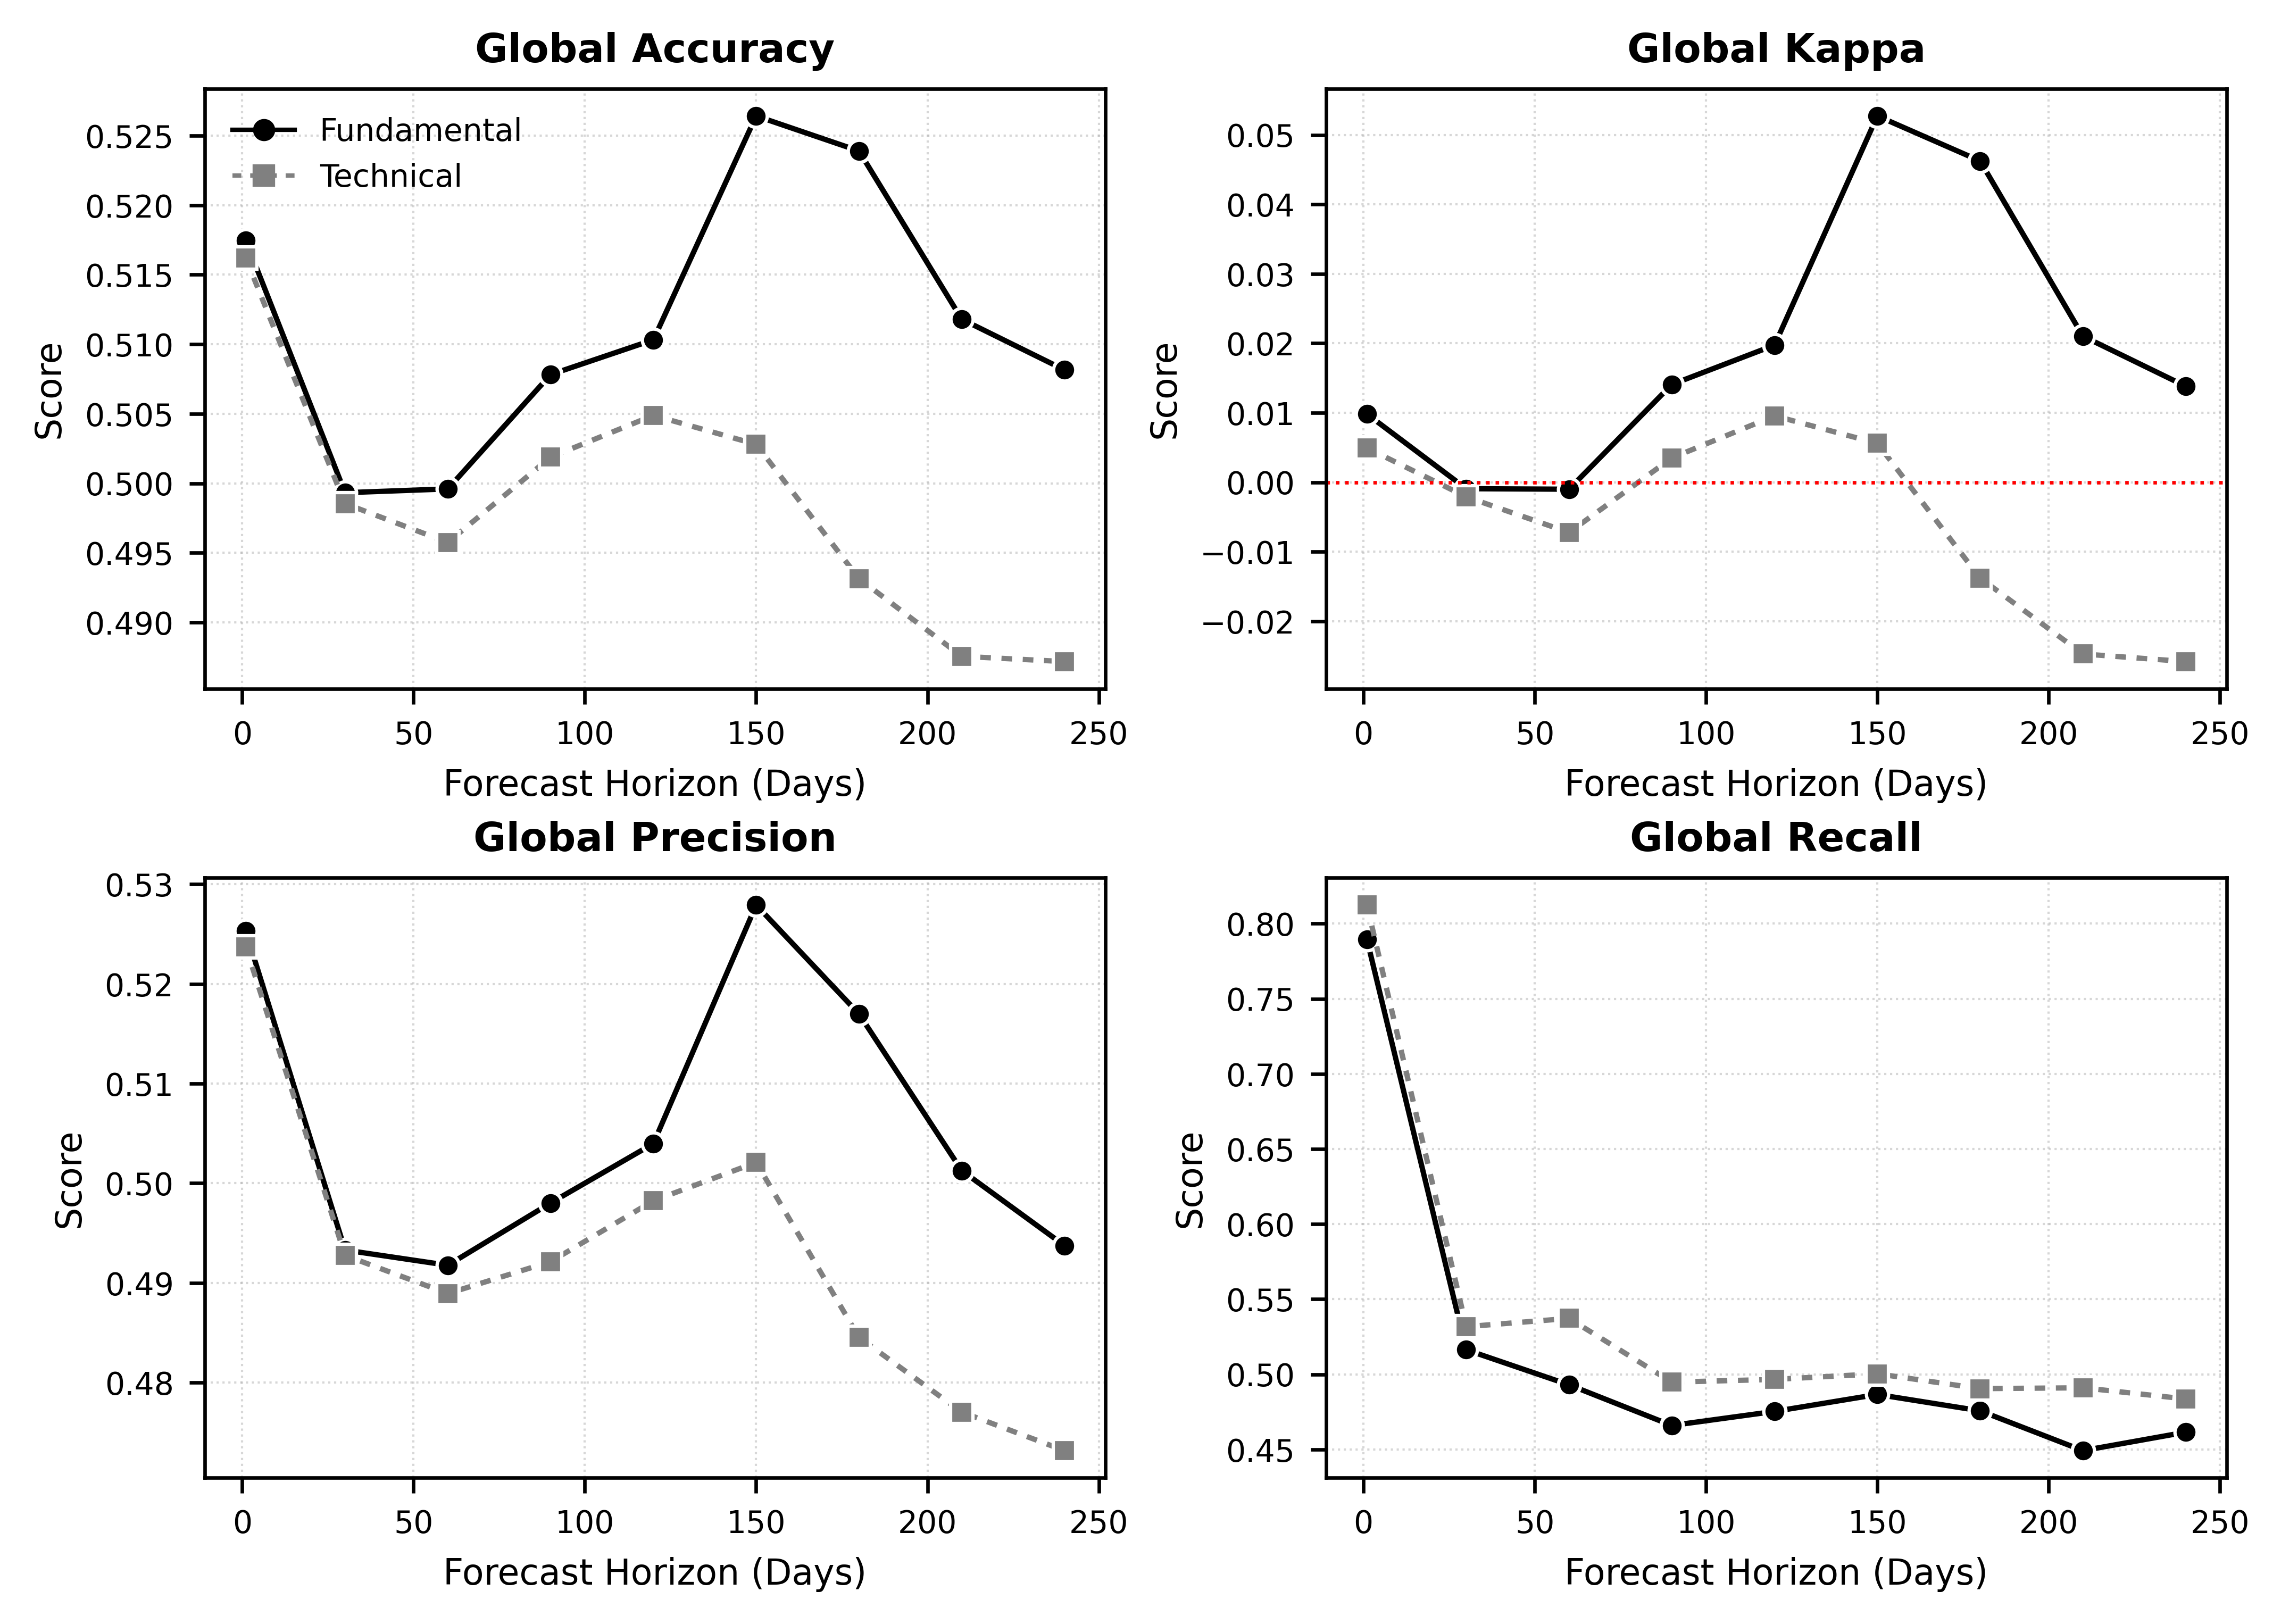

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# CONFIGURAÇÃO IEEE STANDARD
# ==============================================================================
# Largura padrão de coluna IEEE: 3.5 polegadas.
# Se for figura de página inteira (2 colunas), use largura de 7.16 polegadas.
IEEE_COL_WIDTH = 3.5 
IEEE_Y_HEIGHT = 3.5  # Quadrado ou 3/4

plt.rcParams.update({
    'font.family': 'serif',            # Usa fonte com serifa para combinar com o texto
    'font.serif': ['Times New Roman'], # Especificamente Times
    'font.size': 8,                    # Tamanho base (legenda/eixos)
    'axes.labelsize': 8,               # Tamanho dos labels (X/Y)
    'axes.titlesize': 9,               # Tamanho do título (um pouco maior)
    'legend.fontsize': 7,              # Legenda compacta
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,                 # Alta resolução (recomendado 600 para traços)
    'lines.linewidth': 1,              # Linhas mais finas para gráficos pequenos
    'lines.markersize': 4              # Marcadores ajustados
})

# ==============================================================================
# PLOTAGEM AJUSTADA
# ==============================================================================
# Nota: figsize agora define o tamanho REAL de impressão.
fig, axes = plt.subplots(2, 2, figsize=(IEEE_COL_WIDTH * 2, 5), dpi=600) 
# Usei largura dupla (7 polegadas) para seu grid 2x2 ficar legível em 2 colunas.
# Se quiser 1 coluna (vertical), use figsize=(3.5, 6) e mude o layout para 4x1 ou 2x2 apertado.

axes = axes.flatten()

for i, (col_metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    
    sns.lineplot(
        data=df_global, 
        x='fh', 
        y=col_metric, 
        hue='Domain', 
        style='Domain',       
        palette=palette_map,  
        markers=markers_map,  
        dashes=dashes_map,    
        linewidth=1.2,       # Linha levemente mais fina
        markersize=5,        # Marcador proporcional
        ax=ax
    )
    
    # Títulos e Labels limpos
    ax.set_title(title, fontweight='bold') # Fonte já configurada nos params
    ax.set_xlabel('Forecast Horizon (Days)')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle=':', alpha=0.5, linewidth=0.5)
    
    if 'Kappa' in col_metric:
        ax.axhline(0, color='red', linestyle=':', linewidth=0.8)

    if i == 0:
        ax.legend(title='', frameon=False, loc='best') # Remove caixa e título redundante
    else:
        ax.get_legend().remove()

# Layout apertado é crucial para IEEE para não desperdiçar espaço em branco
plt.tight_layout(pad=0.5) 

# Salvar
nome_arquivo_saida = 'global_metrics_fund_vs_tech_per_horizon.pdf'
plt.savefig(nome_arquivo_saida, format='pdf', bbox_inches='tight')
plt.show()